In [1]:
import pandas as pd

df = pd.read_csv("./data/metadata_merged.csv", low_memory=False)
print("shape:", df.shape)                         # 行数、列数
print("columns:", list(df.columns))               # 列名列表
print(df.dtypes.head(20))                         # 前20列的数据类型（可多次改20为更大查看）
print(df.head(3))                                 # 预览前3行，确认关键列是否存在（如 Title/Slug/Tags 等）


shape: (521735, 31)
columns: ['Id', 'Title', 'Slug', 'Tags', 'CreatorUserId', 'OwnerUserId', 'OwnerOrganizationId', 'CurrentDatasetVersionId', 'CurrentDatasourceVersionId', 'ForumId', 'Type', 'CreationDate', 'LastActivityDate', 'TotalViews', 'TotalDownloads', 'TotalVotes', 'TotalKernels', 'Medal', 'MedalAwardDate', 'Subtitle', 'Description', 'CreationDate_dt', 'LastActivityDate_dt', 'age_days', 'days_since_last_activity', 'active_30d', 'has_tags', 'TotalViews_log1p', 'TotalDownloads_log1p', 'TotalVotes_log1p', 'TotalKernels_log1p']
Id                              int64
Title                          object
Slug                           object
Tags                           object
CreatorUserId                   int64
OwnerUserId                   float64
OwnerOrganizationId           float64
CurrentDatasetVersionId       float64
CurrentDatasourceVersionId    float64
ForumId                         int64
Type                           object
CreationDate                   object
LastAc

In [3]:
# —— V1 第1步：从 metadata_merged.csv 提取清洗后的 D–T 边集 —— 
import pandas as pd

df = pd.read_csv("./data/metadata_merged.csv", low_memory=False, usecols=["Id","Tags"])
s = df["Tags"].fillna("").astype(str).str.split(",")                             # 按逗号切分
dt = pd.DataFrame({"Id": df["Id"].repeat(s.str.len()).to_numpy(),
                   "Tag": [t.strip().lower() for sub in s for t in sub]})       # 规范化：去空格、小写
dt = dt[dt["Tag"] != ""]                                                         # 去空标签
dt = dt.drop_duplicates()                                                        # 同一数据集重复标签去重
dt.to_csv("./data/graph_v1_edges.csv", index=False)                              # 保存边集
print("edges saved:", dt.shape, "unique D:", dt["Id"].nunique(), "unique T:", dt["Tag"].nunique())


edges saved: (446064, 2) unique D: 214603 unique T: 597


In [4]:
# —— V1 第2步：过滤稀有/泛化标签并保存 —— 
import pandas as pd, numpy as np

dt = pd.read_csv("./data/graph_v1_edges.csv")
n_d = dt["Id"].nunique(); min_df = 2; max_df_ratio = 0.25
tag_df = dt.groupby("Tag")["Id"].nunique()                   # 每个标签覆盖的数据集数
keep_tags = tag_df[(tag_df >= min_df) & (tag_df <= max_df_ratio * n_d)].index
dt_f = dt[dt["Tag"].isin(keep_tags)].drop_duplicates()

dt_f.to_csv("./data/graph_v1_edges_filtered.csv", index=False)
print("filtered edges:", dt_f.shape, "| D:", dt_f["Id"].nunique(), "| T:", dt_f["Tag"].nunique(),
      "| min_df:", min_df, "| max_df_ratio:", max_df_ratio)


filtered edges: (445997, 2) | D: 214602 | T: 530 | min_df: 2 | max_df_ratio: 0.25


In [5]:
# —— V1 第3步：从二部图生成随机游走语料 ./data/walks.txt ——
import pandas as pd, numpy as np

# 1) 读取过滤后的 D–T 边，构建二部图邻接（分别为 D->T 与 T->D）
dt = pd.read_csv("./data/graph_v1_edges_filtered.csv")
d2t = {}; t2d = {}
for i, r in dt.iterrows():
    d2t.setdefault(r["Id"], []).append(r["Tag"])
    t2d.setdefault(r["Tag"], []).append(r["Id"])

# 2) 设定游走参数（可按需调大/调小）
R = 3          # 每个 D 节点出发的游走条数


In [7]:
# —— V1 第4A步：从 walks.txt 统计 D–D（距离=2：D–T–D）共现对，写入 ./data/dd_pairs.csv ——
import re, numpy as np, pandas as pd

pair_counts = {}
patD, patT = re.compile(r"^D_(\d+)$"), re.compile(r"^T_(.+)$")

with open("./data/walks.txt", "r", encoding="utf-8") as f:
    for line in f:
        toks = line.strip().split()
        # 滑窗长度3：检查 D–T–D
        for i in range(len(toks) - 2):
            m0, m1, m2 = patD.match(toks[i]), patT.match(toks[i+1]), patD.match(toks[i+2])
            if m0 and m1 and m2:
                a = int(m0.group(1)); b = int(m2.group(1))
                if a == b: 
                    continue
                r, c = (a, b) if a < b else (b, a)      # 无向对：去序
                pair_counts[(r, c)] = pair_counts.get((r, c), 0) + 1

# 落盘为三列：d1,d2,count
dd = pd.DataFrame([(k[0], k[1], v) for k, v in pair_counts.items()],
                  columns=["d1","d2","count"])
dd.to_csv("./data/dd_pairs.csv", index=False)
print("pairs saved:", dd.shape, "-> ./data/dd_pairs.csv")


pairs saved: (6255182, 3) -> ./data/dd_pairs.csv


In [8]:
# —— V1 第4B步：SPPMI + TruncatedSVD（从 dd_pairs.csv 得到向量）——
import pandas as pd, numpy as np
from scipy.sparse import coo_matrix, csr_matrix
from sklearn.decomposition import TruncatedSVD

# 1) 读 D–D 共现对并构稀疏共现矩阵（对称化：无向）
dd = pd.read_csv("./data/dd_pairs.csv")
ids = np.unique(pd.concat([dd["d1"], dd["d2"]]).to_numpy())
id2idx = {i:k for k,i in enumerate(ids)}
r = dd["d1"].map(id2idx).to_numpy(); c = dd["d2"].map(id2idx).to_numpy(); v = dd["count"].to_numpy(dtype=np.float32)
C = coo_matrix((v, (r, c)), shape=(len(ids), len(ids)), dtype=np.float32)
C = C + C.T                                   # 对称（D–D 无向）
C = C.tocsr()

# 2) 计算 SPPMI（shifted Positive PMI），仅在非零处
rows, cols = C.nonzero()
vals = C.data
row_sum = np.asarray(C.sum(axis=1)).ravel(); col_sum = np.asarray(C.sum(axis=0)).ravel()
N = float(vals.sum())
neg_k = 5.0
pmi = np.log((vals * N) / (row_sum[rows] * col_sum[cols] + 1e-12) + 1e-12)
sppmi_vals = np.maximum(pmi - np.log(neg_k), 0.0)
mask = sppmi_vals > 0
SPPMI = coo_matrix((sppmi_vals[mask], (rows[mask], cols[mask])), shape=C.shape, dtype=np.float32).tocsr()

# 3) SVD 压到 128 维并 L2 归一化
svd = TruncatedSVD(n_components=128, random_state=42)
Z = svd.fit_transform(SPPMI).astype(np.float32)
Z /= (np.linalg.norm(Z, axis=1, keepdims=True) + 1e-12)

# 4) 保存为 ./data/v1_taggraph_vectors.csv（仅含有边的 D 节点）
out = pd.DataFrame(np.column_stack([ids.astype(np.int64), Z]),
                   columns=["Id"] + [f"f{i}" for i in range(Z.shape[1])])
out.to_csv("./data/v1_taggraph_vectors.csv", index=False)
print("saved:", out.shape, "-> ./data/v1_taggraph_vectors.csv")


saved: (134278, 129) -> ./data/v1_taggraph_vectors.csv


V1 loaded: (134278, 128)
saved clusters -> ./data/v1_clusters.csv | K=21


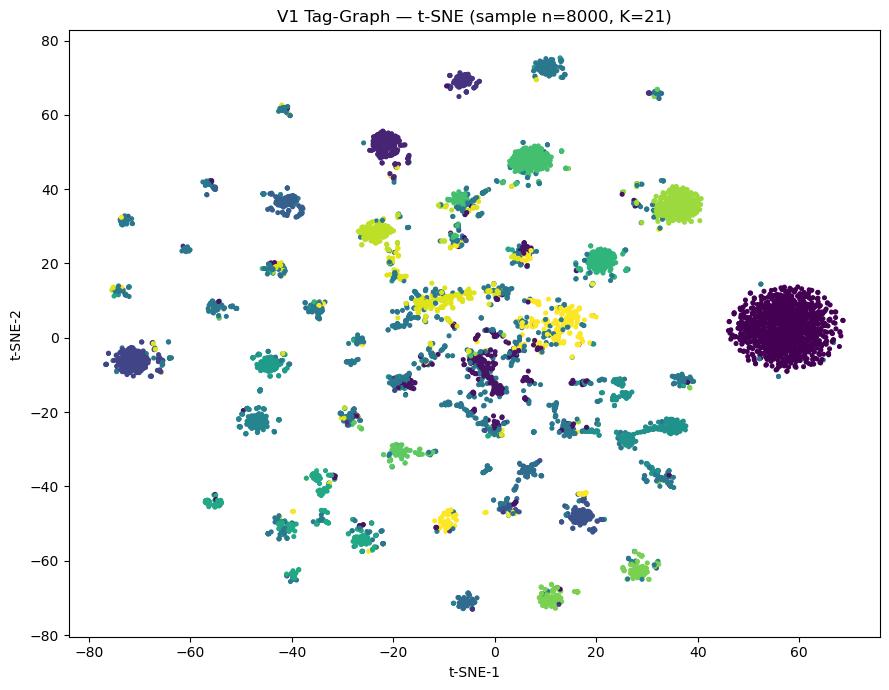

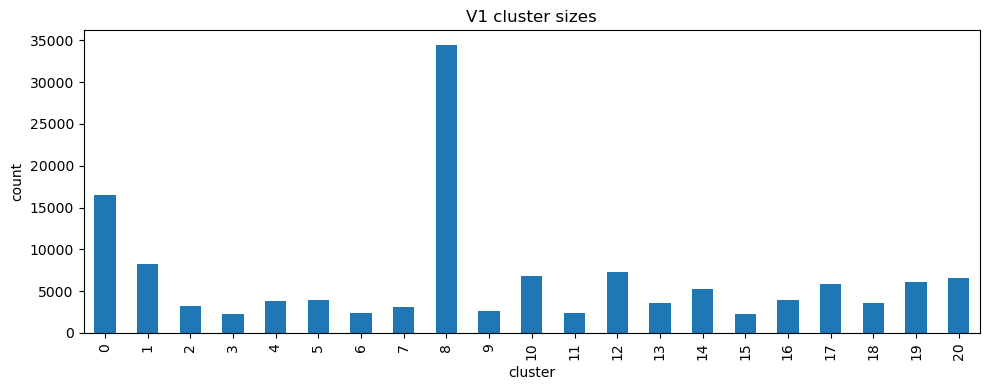

Top-10 cluster sizes:
 8     34472
0     16559
1      8191
12     7321
10     6768
20     6619
19     6041
17     5836
14     5318
16     3963
Name: count, dtype: int64
[V1] silhouette(cosine,n=10000)=0.3878 | DB=2.087 (↓) | CH=5613.6 (↑)


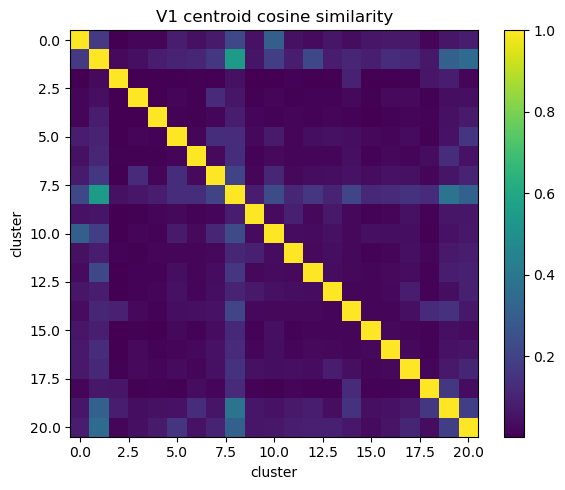

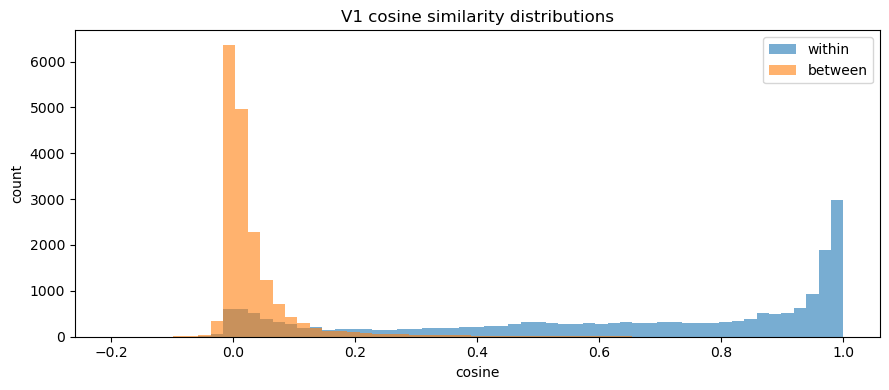

[V1] mean cos — within:0.632 | between:0.034 | centroid-between:0.062


In [20]:
# —— V1 视角：聚类 + 可视化（仅用 v1_taggraph_vectors.csv）——
import pandas as pd, numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

# 1) 读取 V1 嵌入并做 L2 归一化（稳妥起见，再归一一次）
v1 = pd.read_csv("./data/v1_taggraph_vectors.csv")
ids = v1["Id"].to_numpy(np.int64)
X = v1.drop(columns=["Id"]).to_numpy(np.float32)
X /= (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
n, d = X.shape
print("V1 loaded:", X.shape)

# 2) 聚类（MiniBatchKMeans，K 用简单启发式；可后续调参）
K = int(max(5, min(25, round(np.sqrt(max(2000, n)/300)))))  # 约 8~25 之间
kmeans = MiniBatchKMeans(n_clusters=K, random_state=42, batch_size=10000, n_init=10)
labels = kmeans.fit_predict(X)

# 3) 保存聚类结果（仅此视图的簇）
pd.DataFrame({"Id": ids, "label": labels}).to_csv("./data/v1_clusters.csv", index=False)
print(f"saved clusters -> ./data/v1_clusters.csv | K={K}")

# 4) 可视化：抽样 t-SNE（先用 SVD→50D 加速），按簇着色；簇规模柱状图
try:
    import matplotlib.pyplot as plt

    # 4.1 抽样并降维到 2D
    rng = np.random.default_rng(42)
    plot_size = min(8000, n)
    idx = rng.choice(n, size=plot_size, replace=False)
    Z = TruncatedSVD(n_components=min(50, d), random_state=42).fit_transform(X[idx])
    Z /= (np.linalg.norm(Z, axis=1, keepdims=True) + 1e-12)
    perp = int(max(5, min(50, (plot_size - 1)//3, max(5, plot_size//40))))
    Y = TSNE(n_components=2, perplexity=perp, learning_rate=200, init="pca", random_state=42)\
        .fit_transform(Z.astype(np.float32))

    # 4.2 t-SNE 散点（按簇上色，默认 colormap）
    plt.figure(figsize=(9,7))
    plt.scatter(Y[:,0], Y[:,1], s=7, c=labels[idx])
    plt.title(f"V1 Tag-Graph — t-SNE (sample n={plot_size}, K={K})")
    plt.xlabel("t-SNE-1"); plt.ylabel("t-SNE-2")
    plt.tight_layout(); plt.show()

    # 4.3 簇规模柱状图
    sizes = pd.Series(labels).value_counts().sort_index()
    plt.figure(figsize=(10,4))
    sizes.plot(kind="bar")
    plt.title("V1 cluster sizes"); plt.xlabel("cluster"); plt.ylabel("count")
    plt.tight_layout(); plt.show()

    print("Top-10 cluster sizes:\n", sizes.sort_values(ascending=False).head(10))
except Exception as e:
    print("Plotting skipped due to error:", repr(e))

# —— 评估 & 可视化（V1）——
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

FEAT, LAB = X, labels  # 统一别名
m = int(min(10000, FEAT.shape[0]))
idx_eval = np.random.default_rng(42).choice(FEAT.shape[0], size=m, replace=False)

sil = silhouette_score(FEAT[idx_eval], LAB[idx_eval], metric="cosine")
db  = davies_bouldin_score(FEAT, LAB)
ch  = calinski_harabasz_score(FEAT, LAB)
print(f"[V1] silhouette(cosine,n={m})={sil:.4f} | DB={db:.3f} (↓) | CH={ch:.1f} (↑)")

# 质心相似度热图（余弦）
uniq = np.unique(LAB); K = len(uniq)
cent = []
for k in uniq:
    mk = (LAB==k)
    c = FEAT[mk].mean(axis=0); c /= (np.linalg.norm(c)+1e-12)
    cent.append(c)
Cmat = np.vstack(cent) @ np.vstack(cent).T
plt.figure(figsize=(6,5))
plt.imshow(Cmat, aspect="auto"); plt.colorbar(); plt.title("V1 centroid cosine similarity")
plt.xlabel("cluster"); plt.ylabel("cluster"); plt.tight_layout(); plt.show()

# 组内/组间相似度分布（抽样）
rng = np.random.default_rng(1)
bins = np.linspace(-0.2, 1.0, 60)

# 组内：各簇均匀抽样
s_in = []
for k in uniq:
    idxk = np.where(LAB==k)[0]
    if idxk.size < 2: continue
    s = min(20000//len(uniq), idxk.size)
    a = rng.choice(idxk, size=s, replace=True)
    b = rng.choice(idxk, size=s, replace=True)
    s_in.append(np.sum(FEAT[a]*FEAT[b], axis=1))
s_in = np.concatenate(s_in) if len(s_in) else np.array([])

# 组间：全局随机对，过滤不同簇
s = 20000
a = rng.choice(FEAT.shape[0], size=s, replace=True)
b = rng.choice(FEAT.shape[0], size=s, replace=True)
mask = LAB[a] != LAB[b]
s_out = np.sum(FEAT[a[mask]]*FEAT[b[mask]], axis=1)

plt.figure(figsize=(9,4))
plt.hist(s_in, bins=bins, alpha=0.6, label="within")
plt.hist(s_out, bins=bins, alpha=0.6, label="between")
plt.legend(); plt.title("V1 cosine similarity distributions"); plt.xlabel("cosine"); plt.ylabel("count")
plt.tight_layout(); plt.show()

# 组内/组间均值（以及质心间均值）
off = Cmat[~np.eye(K, dtype=bool)]
print(f"[V1] mean cos — within:{np.nanmean(s_in):.3f} | between:{np.nanmean(s_out):.3f} | centroid-between:{off.mean():.3f}")



In [15]:
# —— V2(Text-Graph) 第1步：长文本 → Top-K 关键词（作为 D–W 边），导出 ./data/textgraph_edges.csv ——
import re, pandas as pd, numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

# 1) 读取 & 字段加权（Title:Subtitle:Description = 3:1:1），并做基础清洗
df = pd.read_csv("./data/metadata_merged.csv", low_memory=False, usecols=["Id","Title","Subtitle","Description"])

title = df["Title"].fillna("").astype(str)
subt  = df["Subtitle"].fillna("").astype(str)
desc  = df["Description"].fillna("").astype(str)

# 基础清洗：去代码片段、URL、强标点清洗与多空白
title = title.str.replace(r"`{1,3}.*?`{1,3}", " ", regex=True)\
             .str.replace(r"https?://\S+|www\.\S+", " ", regex=True)\
             .str.replace(r"[^\w\s\-+#./]", " ", regex=True)\
             .str.replace(r"\s+", " ", regex=True).str.strip()

subt  = subt.str.replace(r"`{1,3}.*?`{1,3}", " ", regex=True)\
            .str.replace(r"https?://\S+|www\.\S+", " ", regex=True)\
            .str.replace(r"[^\w\s\-+#./]", " ", regex=True)\
            .str.replace(r"\s+", " ", regex=True).str.strip()

desc  = desc.str.replace(r"`{1,3}.*?`{1,3}", " ", regex=True)\
            .str.replace(r"https?://\S+|www\.\S+", " ", regex=True)\
            .str.replace(r"[^\w\s\-+#./]", " ", regex=True)\
            .str.replace(r"\s+", " ", regex=True).str.strip()

# 3:1:1 组合并小写
text = (title + " " + title + " " + title + " " + subt + " " + desc).str.lower()

# 2) TF-IDF（1–2gram，控制词表；加入英文停用词 ∪ 领域停用词）
extra_stop = {"dataset","kaggle","csv","data","notebook","kernel","click","file","table","tutorial","competition"}
stop = list(ENGLISH_STOP_WORDS.union(extra_stop))  # ★ 关键修正：传 list[str] 给 stop_words

tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=5,               # 过滤极稀有词
    max_df=0.05,            # 过滤极常见词（>5% 文档）
    max_features=100_000,   # 控制词表规模
    stop_words=stop
)
X = tfidf.fit_transform(text)                 # 稀疏 CSR (N, F)
vocab = np.array(tfidf.get_feature_names_out())

# 3) 每文档取 Top-K 关键词并做 L1 归一化作为边权
K = 30
ids = df["Id"].to_numpy(np.int64)

rows, cols, weights = [], [], []
indptr, indices, data = X.indptr, X.indices, X.data  # 直接访问 CSR 结构以加速
for i in range(X.shape[0]):
    start, end = indptr[i], indptr[i+1]
    if start == end:
        continue
    di = data[start:end]
    ii = indices[start:end]
    if di.size > K:
        sel = np.argpartition(di, -K)[-K:]  # Top-K 无序索引（比完整排序快）
    else:
        sel = np.arange(di.size)
    tok_ids = ii[sel]
    vals = di[sel].astype(np.float32)
    vals = vals / (vals.sum() + 1e-12)      # 文档内 L1 归一成边权

    rows.extend([ids[i]] * tok_ids.size)
    cols.extend(vocab[tok_ids].tolist())
    weights.extend(vals.tolist())

edges = pd.DataFrame({
    "Id": np.array(rows, dtype=np.int64),
    "token": np.array(cols, dtype=object),
    "weight": np.array(weights, dtype=np.float32)
})
edges.drop_duplicates(subset=["Id","token"], inplace=True)  # 守一下“同词多次”的极端情况
edges.to_csv("./data/textgraph_edges.csv", index=False)

print("edges saved:", edges.shape,
      "| unique D:", edges["Id"].nunique(),
      "| unique W:", edges["token"].nunique())


edges saved: (3929623, 3) | unique D: 344281 | unique W: 96879


In [16]:
# —— V2(Text-Graph) 第2步：按边权随机游走（D→W→D…），生成 ./data/text_walks.txt ——
import pandas as pd, numpy as np

# 1) 读取 D–W 边（含文档内归一化权重）并构建邻接：D→W 与 W→D（分别在各自邻域内再归一）
edges = pd.read_csv("./data/textgraph_edges.csv")
# D -> W
d2w_tokens = {}
d2w_probs  = {}
for d, grp in edges.groupby("Id", sort=False):
    toks = grp["token"].to_numpy(object)
    ps   = grp["weight"].to_numpy(np.float32)
    ps   = ps / (ps.sum() + 1e-12)
    d2w_tokens[int(d)] = toks
    d2w_probs[int(d)]  = ps
# W -> D
w2d_nodes = {}
w2d_probs = {}
for w, grp in edges.groupby("token", sort=False):
    ds = grp["Id"].to_numpy(np.int64)
    ws = grp["weight"].to_numpy(np.float32)
    ws = ws / (ws.sum() + 1e-12)
    w2d_nodes[w] = ds
    w2d_probs[w] = ws

# 2) 随机游走参数（可按需调大/调小）
R = 3        # 每个 D 节点出发的游走条数
L = 40       # 每条游走长度（token 数）
rng = np.random.default_rng(42)
Ds = np.array(list(d2w_tokens.keys()), dtype=np.int64)

# 3) 交替游走并写盘：一行一个句子（形如 D_123 W_time_series D_456 …）
with open("./data/text_walks.txt", "w", encoding="utf-8") as f:
    for d in Ds:
        toks = d2w_tokens.get(d, None)
        if toks is None or toks.size == 0:
            continue
        for _ in range(R):
            sent = [f"D_{d}"]
            cur_is_d, cur_d, cur_w = True, d, None
            for _ in range(L-1):
                if cur_is_d:
                    toks = d2w_tokens.get(cur_d, None)
                    if toks is None or toks.size == 0: break
                    ps   = d2w_probs[cur_d]
                    cur_w = toks[rng.choice(toks.size, p=ps)]
                    sent.append(f"W_{cur_w}")
                else:
                    ds = w2d_nodes.get(cur_w, None)
                    if ds is None or ds.size == 0: break
                    ps = w2d_probs[cur_w]
                    cur_d = int(ds[rng.choice(ds.size, p=ps)])
                    sent.append(f"D_{cur_d}")
                cur_is_d = not cur_is_d
            f.write(" ".join(sent) + "\n")

print("walks saved to ./data/text_walks.txt",
      "| D nodes:", len(Ds), "| R:", R, "| L:", L)


walks saved to ./data/text_walks.txt | D nodes: 344281 | R: 3 | L: 40


In [17]:
# —— V2 第3步：从 text_walks.txt 统计 D–D 共现（D–W–D），保存 ./data/text_dd_pairs.csv ——
import re, pandas as pd

pair_counts = {}
patD, patW = re.compile(r"^D_(\d+)$"), re.compile(r"^W_(.+)$")

with open("./data/text_walks.txt", "r", encoding="utf-8") as f:
    for line in f:
        toks = line.strip().split()
        # 滑窗长度3：匹配 D–W–D
        for i in range(len(toks) - 2):
            m0, m1, m2 = patD.match(toks[i]), patW.match(toks[i+1]), patD.match(toks[i+2])
            if m0 and m1 and m2:
                a = int(m0.group(1)); b = int(m2.group(1))
                if a == b: 
                    continue
                r, c = (a, b) if a < b else (b, a)   # 无向对：去序
                pair_counts[(r, c)] = pair_counts.get((r, c), 0) + 1

# 落盘：三列 d1,d2,count
dd = pd.DataFrame([(k[0], k[1], v) for k, v in pair_counts.items()],
                  columns=["d1","d2","count"])
dd.to_csv("./data/text_dd_pairs.csv", index=False)

print("pairs saved:", dd.shape, "-> ./data/text_dd_pairs.csv")


pairs saved: (10698426, 3) -> ./data/text_dd_pairs.csv


saved vectors: (344241, 129) -> ./data/v2_textgraph_vectors.csv
saved clusters -> ./data/v2_textgraph_clusters.csv | K=30


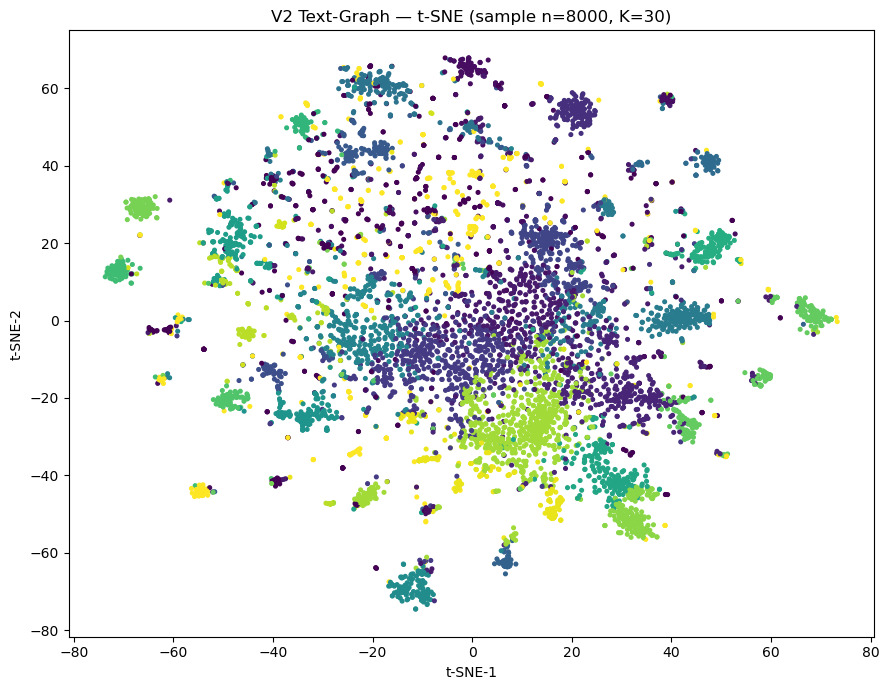

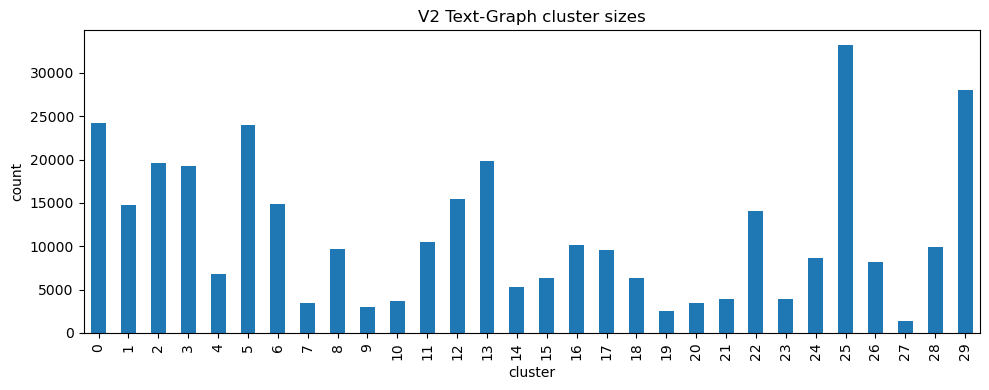

Top-10 cluster sizes:
 25    33254
29    28072
0     24273
5     24045
13    19785
2     19664
3     19266
12    15400
6     14876
1     14710
Name: count, dtype: int64
[V2] silhouette(cosine,n=10000)=0.1180 | DB=3.055 (↓) | CH=6207.9 (↑)


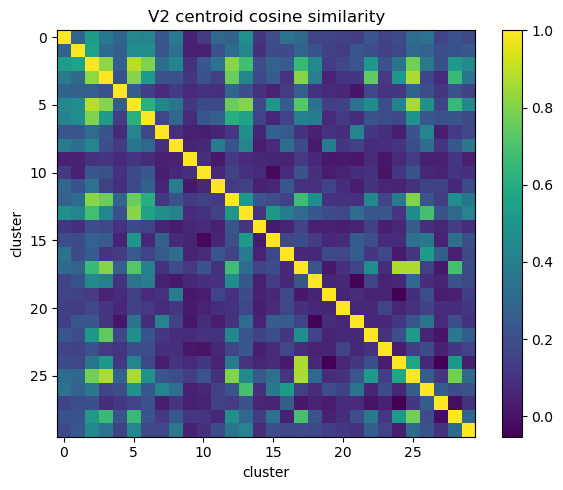

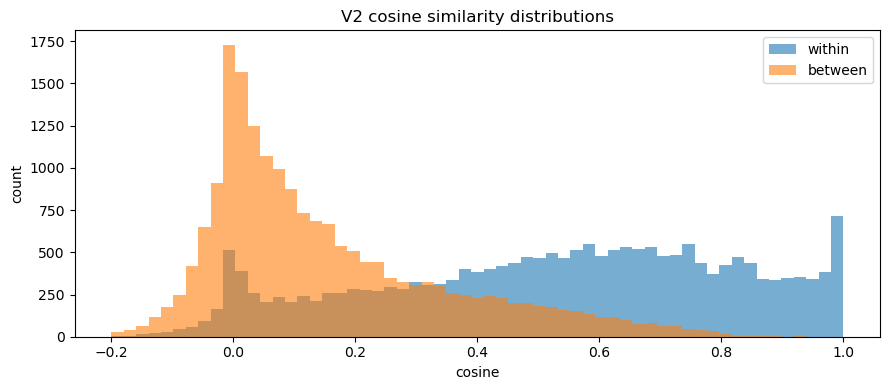

[V2] mean cos — within:0.526 | between:0.152 | centroid-between:0.220


In [21]:
# —— V2(Text-Graph) 第4步：SPPMI + TruncatedSVD → 文本图向量；并做单视角聚类与可视化 ——
import pandas as pd, numpy as np
from scipy.sparse import coo_matrix, csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import MiniBatchKMeans

# 1) 读入 D–D 共现对，并构建对称稀疏共现矩阵 C
dd = pd.read_csv("./data/text_dd_pairs.csv")                  # 列：d1,d2,count
ids = np.unique(pd.concat([dd["d1"], dd["d2"]]).to_numpy())   # 参与过共现的 D 节点
id2idx = {i:k for k,i in enumerate(ids)}
r = dd["d1"].map(id2idx).to_numpy()
c = dd["d2"].map(id2idx).to_numpy()
v = dd["count"].astype(np.float32).to_numpy()
C = coo_matrix((v, (r, c)), shape=(len(ids), len(ids)), dtype=np.float32)
C = (C + C.T).tocsr()                                         # 无向对称化

# 2) 计算 SPPMI（在非零处），并构建稀疏 SPPMI 矩阵
rows, cols = C.nonzero()
vals = C.data
row_sum = np.asarray(C.sum(axis=1)).ravel()
col_sum = np.asarray(C.sum(axis=0)).ravel()
N = float(vals.sum())
neg_k = 5.0
pmi = np.log((vals * N) / (row_sum[rows] * col_sum[cols] + 1e-12) + 1e-12)
sppmi_vals = np.maximum(pmi - np.log(neg_k), 0.0)
mask = sppmi_vals > 0
SPPMI = coo_matrix((sppmi_vals[mask], (rows[mask], cols[mask])), shape=C.shape, dtype=np.float32).tocsr()

# 3) TruncatedSVD → 128维向量，并做 L2 归一化；保存向量
svd = TruncatedSVD(n_components=128, random_state=42)
Z = svd.fit_transform(SPPMI).astype(np.float32)
Z /= (np.linalg.norm(Z, axis=1, keepdims=True) + 1e-12)
v2tg = pd.DataFrame(np.column_stack([ids.astype(np.int64), Z]),
                    columns=["Id"] + [f"f{i}" for i in range(Z.shape[1])])
v2tg.to_csv("./data/v2_textgraph_vectors.csv", index=False)
print("saved vectors:", v2tg.shape, "-> ./data/v2_textgraph_vectors.csv")

# 4) （仅此视图）聚类：MiniBatchKMeans（K 简单启发式），保存标签
X = Z
n = X.shape[0]
K = int(max(6, min(30, round(np.sqrt(max(2000, n)/250)))))    # 约 8~30 之间
kmeans = MiniBatchKMeans(n_clusters=K, random_state=42, batch_size=10000, n_init=10)
labels = kmeans.fit_predict(X)
pd.DataFrame({"Id": ids.astype(np.int64), "label": labels}).to_csv("./data/v2_textgraph_clusters.csv", index=False)
print(f"saved clusters -> ./data/v2_textgraph_clusters.csv | K={K}")

# 5) 可视化：抽样 t-SNE（先 SVD→50D 加速），按簇着色 + 簇规模柱状图
try:
    import matplotlib.pyplot as plt
    from sklearn.decomposition import TruncatedSVD as SVD50
    from sklearn.manifold import TSNE

    rng = np.random.default_rng(42)
    plot_size = min(8000, n)
    idx = rng.choice(n, size=plot_size, replace=False)

    Z50 = SVD50(n_components=min(50, X.shape[1]), random_state=42).fit_transform(X[idx])
    Z50 /= (np.linalg.norm(Z50, axis=1, keepdims=True) + 1e-12)
    perp = int(max(5, min(50, (plot_size - 1)//3, max(5, plot_size//40))))
    Y = TSNE(n_components=2, perplexity=perp, learning_rate=200, init="pca", random_state=42)\
        .fit_transform(Z50.astype(np.float32))

    plt.figure(figsize=(9,7))
    plt.scatter(Y[:,0], Y[:,1], s=7, c=labels[idx])
    plt.title(f"V2 Text-Graph — t-SNE (sample n={plot_size}, K={K})")
    plt.xlabel("t-SNE-1"); plt.ylabel("t-SNE-2")
    plt.tight_layout(); plt.show()

    sizes = pd.Series(labels).value_counts().sort_index()
    plt.figure(figsize=(10,4))
    sizes.plot(kind="bar")
    plt.title("V2 Text-Graph cluster sizes"); plt.xlabel("cluster"); plt.ylabel("count")
    plt.tight_layout(); plt.show()

    print("Top-10 cluster sizes:\n", sizes.sort_values(ascending=False).head(10))
except Exception as e:
    print("Plotting skipped due to error:", repr(e))

# —— 评估 & 可视化（V2 Text-Graph）——
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

FEAT, LAB = X, labels
m = int(min(10000, FEAT.shape[0]))
idx_eval = np.random.default_rng(42).choice(FEAT.shape[0], size=m, replace=False)

sil = silhouette_score(FEAT[idx_eval], LAB[idx_eval], metric="cosine")
db  = davies_bouldin_score(FEAT, LAB)
ch  = calinski_harabasz_score(FEAT, LAB)
print(f"[V2] silhouette(cosine,n={m})={sil:.4f} | DB={db:.3f} (↓) | CH={ch:.1f} (↑)")

uniq = np.unique(LAB); K = len(uniq)
cent = []
for k in uniq:
    mk = (LAB==k)
    c = FEAT[mk].mean(axis=0); c /= (np.linalg.norm(c)+1e-12)
    cent.append(c)
Cmat = np.vstack(cent) @ np.vstack(cent).T
plt.figure(figsize=(6,5))
plt.imshow(Cmat, aspect="auto"); plt.colorbar(); plt.title("V2 centroid cosine similarity")
plt.xlabel("cluster"); plt.ylabel("cluster"); plt.tight_layout(); plt.show()

rng = np.random.default_rng(1)
bins = np.linspace(-0.2, 1.0, 60)

s_in = []
for k in uniq:
    idxk = np.where(LAB==k)[0]
    if idxk.size < 2: continue
    s = min(20000//len(uniq), idxk.size)
    a = rng.choice(idxk, size=s, replace=True)
    b = rng.choice(idxk, size=s, replace=True)
    s_in.append(np.sum(FEAT[a]*FEAT[b], axis=1))
s_in = np.concatenate(s_in) if len(s_in) else np.array([])

s = 20000
a = rng.choice(FEAT.shape[0], size=s, replace=True)
b = rng.choice(FEAT.shape[0], size=s, replace=True)
mask = LAB[a] != LAB[b]
s_out = np.sum(FEAT[a[mask]]*FEAT[b[mask]], axis=1)

plt.figure(figsize=(9,4))
plt.hist(s_in, bins=bins, alpha=0.6, label="within")
plt.hist(s_out, bins=bins, alpha=0.6, label="between")
plt.legend(); plt.title("V2 cosine similarity distributions"); plt.xlabel("cosine"); plt.ylabel("count")
plt.tight_layout(); plt.show()

off = Cmat[~np.eye(K, dtype=bool)]
print(f"[V2] mean cos — within:{np.nanmean(s_in):.3f} | between:{np.nanmean(s_out):.3f} | centroid-between:{off.mean():.3f}")


aligned rows: 132485 | v1 only: 1793 | v2 only: 211756
fused shape: (132485, 256)
saved vectors -> ./data/v12_fused_vectors.csv
saved clusters -> ./data/v12_clusters.csv | K=23


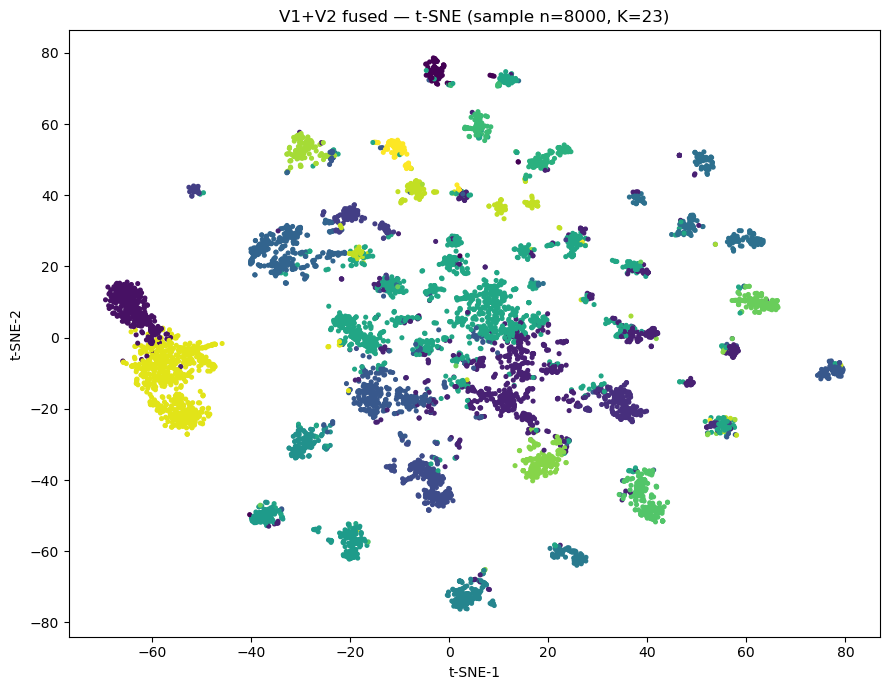

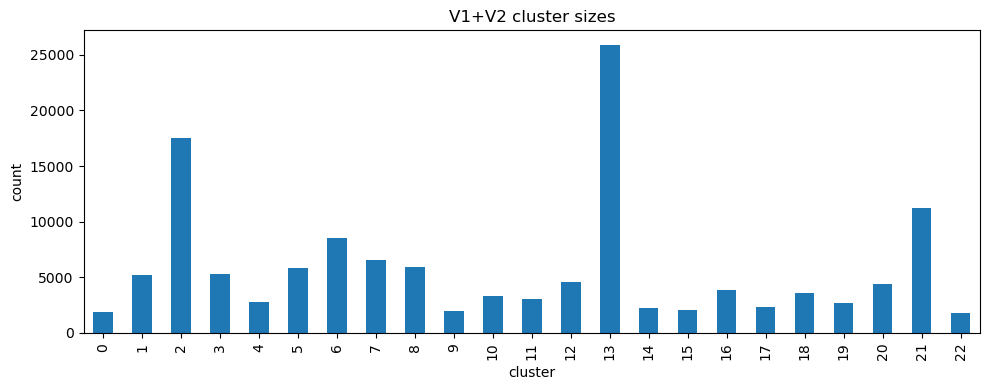

Top-10 cluster sizes:
 13    25896
2     17500
21    11229
6      8573
7      6599
8      5885
5      5803
3      5283
1      5181
12     4620
Name: count, dtype: int64
[V1+V2] silhouette(cosine,n=10000)=0.2340 | DB=2.476 (↓) | CH=3558.6 (↑)


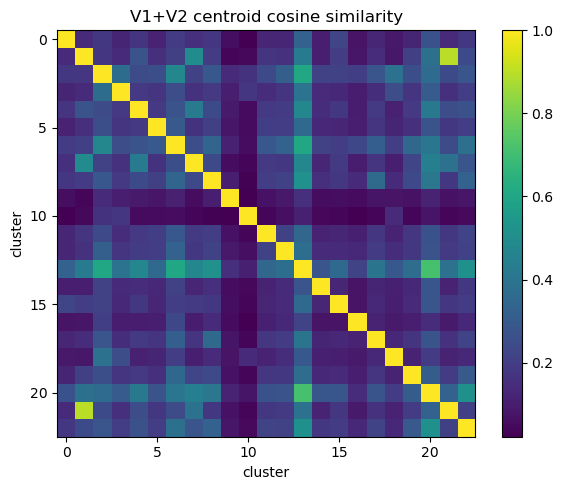

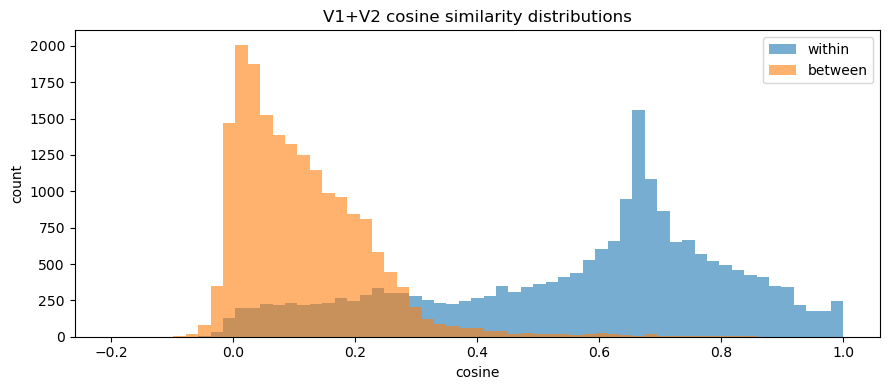

[V1+V2] mean cos — within:0.565 | between:0.113 | centroid-between:0.201


In [22]:
# —— 融合 V1(标签图) + V2(文本图) → 向量拼接 → 聚类 & 可视化 ——
import pandas as pd, numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

# 1) 读取两视角向量并按 Id 对齐（内连接：只保留同时存在于两视角的样本）
v1 = pd.read_csv("./data/v1_taggraph_vectors.csv")        # 列：Id,f0..f127
v2 = pd.read_csv("./data/v2_textgraph_vectors.csv")       # 列：Id,f0..f127
df = v1.merge(v2, on="Id", suffixes=("_v1","_v2"), how="inner")
print("aligned rows:", df.shape[0], "| v1 only:", len(v1)-len(df), "| v2 only:", len(v2)-len(df))

# 2) 取出两块特征并各自 L2 归一化，然后加权拼接（早期融合）
ids = df["Id"].to_numpy(np.int64)
X1 = df.filter(regex=r"^f\d+_v1$").to_numpy(np.float32)
X2 = df.filter(regex=r"^f\d+_v2$").to_numpy(np.float32)

X1 /= (np.linalg.norm(X1, axis=1, keepdims=True) + 1e-12)
X2 /= (np.linalg.norm(X2, axis=1, keepdims=True) + 1e-12)

λ1, λ2 = 1.0, 0.7   # 视角权重（可调：标签图更重，文本图稍轻）
Z = np.concatenate([λ1*X1, λ2*X2], axis=1).astype(np.float32)

# 最终再做一次 L2 归一化，便于用余弦度量
Z /= (np.linalg.norm(Z, axis=1, keepdims=True) + 1e-12)
print("fused shape:", Z.shape)

# 3) 保存融合向量
out = pd.DataFrame(np.column_stack([ids, Z]), columns=["Id"] + [f"f{i}" for i in range(Z.shape[1])])
out.to_csv("./data/v12_fused_vectors.csv", index=False)
print("saved vectors -> ./data/v12_fused_vectors.csv")

# 4) 聚类（MiniBatchKMeans；K 用简易启发式，可按需改）
n = Z.shape[0]
K = int(max(8, min(30, round(np.sqrt(max(2000, n)/250)))))  # 约 8~30
kmeans = MiniBatchKMeans(n_clusters=K, random_state=42, batch_size=10000, n_init=10)
labels = kmeans.fit_predict(Z)

pd.DataFrame({"Id": ids, "label": labels}).to_csv("./data/v12_clusters.csv", index=False)
print(f"saved clusters -> ./data/v12_clusters.csv | K={K}")

# 5) 可视化（抽样 t-SNE；如环境图形库异常会自动跳过）
try:
    import matplotlib.pyplot as plt

    rng = np.random.default_rng(42)
    plot_size = min(8000, n)
    idx = rng.choice(n, size=plot_size, replace=False)

    # 先用 SVD 压到 50 维，加速 t-SNE
    Z50 = TruncatedSVD(n_components=min(50, Z.shape[1]), random_state=42).fit_transform(Z[idx])
    Z50 /= (np.linalg.norm(Z50, axis=1, keepdims=True) + 1e-12)

    perp = int(max(5, min(50, (plot_size - 1)//3, max(5, plot_size//40))))
    Y = TSNE(n_components=2, perplexity=perp, learning_rate=200, init="pca", random_state=42)\
        .fit_transform(Z50.astype(np.float32))

    plt.figure(figsize=(9,7))
    plt.scatter(Y[:,0], Y[:,1], s=7, c=labels[idx])
    plt.title(f"V1+V2 fused — t-SNE (sample n={plot_size}, K={K})")
    plt.xlabel("t-SNE-1"); plt.ylabel("t-SNE-2")
    plt.tight_layout(); plt.show()

    sizes = pd.Series(labels).value_counts().sort_index()
    plt.figure(figsize=(10,4))
    sizes.plot(kind="bar")
    plt.title("V1+V2 cluster sizes"); plt.xlabel("cluster"); plt.ylabel("count")
    plt.tight_layout(); plt.show()

    print("Top-10 cluster sizes:\n", sizes.sort_values(ascending=False).head(10))
except Exception as e:
    print("Plotting skipped due to error:", repr(e))

# —— 评估 & 可视化（V1+V2 融合）——
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

FEAT, LAB = Z, labels
m = int(min(10000, FEAT.shape[0]))
idx_eval = np.random.default_rng(42).choice(FEAT.shape[0], size=m, replace=False)

sil = silhouette_score(FEAT[idx_eval], LAB[idx_eval], metric="cosine")
db  = davies_bouldin_score(FEAT, LAB)
ch  = calinski_harabasz_score(FEAT, LAB)
print(f"[V1+V2] silhouette(cosine,n={m})={sil:.4f} | DB={db:.3f} (↓) | CH={ch:.1f} (↑)")

uniq = np.unique(LAB); K = len(uniq)
cent = []
for k in uniq:
    mk = (LAB==k)
    c = FEAT[mk].mean(axis=0); c /= (np.linalg.norm(c)+1e-12)
    cent.append(c)
Cmat = np.vstack(cent) @ np.vstack(cent).T
plt.figure(figsize=(6,5))
plt.imshow(Cmat, aspect="auto"); plt.colorbar(); plt.title("V1+V2 centroid cosine similarity")
plt.xlabel("cluster"); plt.ylabel("cluster"); plt.tight_layout(); plt.show()

rng = np.random.default_rng(1)
bins = np.linspace(-0.2, 1.0, 60)

s_in = []
for k in uniq:
    idxk = np.where(LAB==k)[0]
    if idxk.size < 2: continue
    s = min(20000//len(uniq), idxk.size)
    a = rng.choice(idxk, size=s, replace=True)
    b = rng.choice(idxk, size=s, replace=True)
    s_in.append(np.sum(FEAT[a]*FEAT[b], axis=1))
s_in = np.concatenate(s_in) if len(s_in) else np.array([])

s = 20000
a = rng.choice(FEAT.shape[0], size=s, replace=True)
b = rng.choice(FEAT.shape[0], size=s, replace=True)
mask = LAB[a] != LAB[b]
s_out = np.sum(FEAT[a[mask]]*FEAT[b[mask]], axis=1)

plt.figure(figsize=(9,4))
plt.hist(s_in, bins=bins, alpha=0.6, label="within")
plt.hist(s_out, bins=bins, alpha=0.6, label="between")
plt.legend(); plt.title("V1+V2 cosine similarity distributions"); plt.xlabel("cosine"); plt.ylabel("count")
plt.tight_layout(); plt.show()

off = Cmat[~np.eye(K, dtype=bool)]
print(f"[V1+V2] mean cos — within:{np.nanmean(s_in):.3f} | between:{np.nanmean(s_out):.3f} | centroid-between:{off.mean():.3f}")



In [23]:
# —— V3 行为视角 · 第1步：选取/派生特征 + 去极值（不做降维），保存临时表 ——
import pandas as pd, numpy as np

# 1) 读取所需列
df = pd.read_csv("./data/metadata_merged.csv", low_memory=False,
                 usecols=["Id","TotalViews_log1p","TotalDownloads_log1p","TotalVotes_log1p","TotalKernels_log1p",
                          "Medal","age_days","days_since_last_activity","active_30d"])

# 2) 派生“对数比值”特征（≈ 转化率/效率的 log 形式，鲁棒于尺度）
df["log_ratio_votes_per_download"] = df["TotalVotes_log1p"] - df["TotalDownloads_log1p"]
df["log_ratio_kernels_per_view"]   = df["TotalKernels_log1p"] - df["TotalViews_log1p"]

# 3) 缺失填充/类型整理
df["Medal"] = df["Medal"].fillna(0).astype(np.float32)
df["active_30d"] = df["active_30d"].astype(bool).astype(np.int8)
for c in ["TotalViews_log1p","TotalDownloads_log1p","TotalVotes_log1p","TotalKernels_log1p",
          "age_days","days_since_last_activity","log_ratio_votes_per_download","log_ratio_kernels_per_view"]:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(np.float32)

# 4) 分位裁剪（Winsorize）以抑制长尾极值影响（对数后仍有尾部）
feat_cols = ["TotalViews_log1p","TotalDownloads_log1p","TotalVotes_log1p","TotalKernels_log1p",
             "Medal","age_days","days_since_last_activity",
             "log_ratio_votes_per_download","log_ratio_kernels_per_view"]
q_low  = df[feat_cols].quantile(0.005)
q_high = df[feat_cols].quantile(0.995)
df[feat_cols] = df[feat_cols].clip(lower=q_low, upper=q_high, axis=1)

# 5) 保存临时行为特征表（下一步再做标准化→PCA→向量导出）
df.to_csv("./data/v3_behavior_features_tmp.csv", index=False)
print("saved tmp features:", df.shape, "-> ./data/v3_behavior_features_tmp.csv")
print("feature columns:", ["Id","active_30d"]+feat_cols)


saved tmp features: (521735, 11) -> ./data/v3_behavior_features_tmp.csv
feature columns: ['Id', 'active_30d', 'TotalViews_log1p', 'TotalDownloads_log1p', 'TotalVotes_log1p', 'TotalKernels_log1p', 'Medal', 'age_days', 'days_since_last_activity', 'log_ratio_votes_per_download', 'log_ratio_kernels_per_view']


In [24]:
# —— V3 行为视角 · 第2步：Robust 标准化 → PCA(8维) → L2 归一 → 保存向量 ——
import pandas as pd, numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA

# 1) 读入第1步产物（包含裁剪后的行为特征）
df = pd.read_csv("./data/v3_behavior_features_tmp.csv", low_memory=False)

# 2) 组装特征矩阵（包含 log1p 行为、勋章、时间、以及两项“对数比值”，再加 active_30d）
feat_cols = ["TotalViews_log1p","TotalDownloads_log1p","TotalVotes_log1p","TotalKernels_log1p",
             "Medal","age_days","days_since_last_activity",
             "log_ratio_votes_per_download","log_ratio_kernels_per_view","active_30d"]
X = df[feat_cols].to_numpy(np.float32)

# 3) Robust 标准化（对长尾更稳健，按中位数/IQR 缩放）
sc = RobustScaler(with_centering=True, with_scaling=True, quantile_range=(10.0, 90.0))
Xs = sc.fit_transform(X).astype(np.float32)

# 4) PCA 降到 8 维（规模更小、去相关）；并做 L2 归一化便于余弦度量
pca = PCA(n_components=min(8, Xs.shape[1]), random_state=42)
Z = pca.fit_transform(Xs).astype(np.float32)
Z /= (np.linalg.norm(Z, axis=1, keepdims=True) + 1e-12)

# 5) 保存向量到 ./data/v3_behavior_vectors.csv（列：Id,f0..f7）
out = pd.DataFrame(np.column_stack([df["Id"].to_numpy(np.int64), Z]),
                   columns=["Id"] + [f"f{i}" for i in range(Z.shape[1])])
out.to_csv("./data/v3_behavior_vectors.csv", index=False)

print("saved vectors:", out.shape, "-> ./data/v3_behavior_vectors.csv",
      "| PCA explained_variance_sum =", float(pca.explained_variance_ratio_.sum()))


saved vectors: (521735, 9) -> ./data/v3_behavior_vectors.csv | PCA explained_variance_sum = 0.9999303221702576


V3 loaded: (521735, 8)
saved clusters -> ./data/v3_clusters.csv | K=30


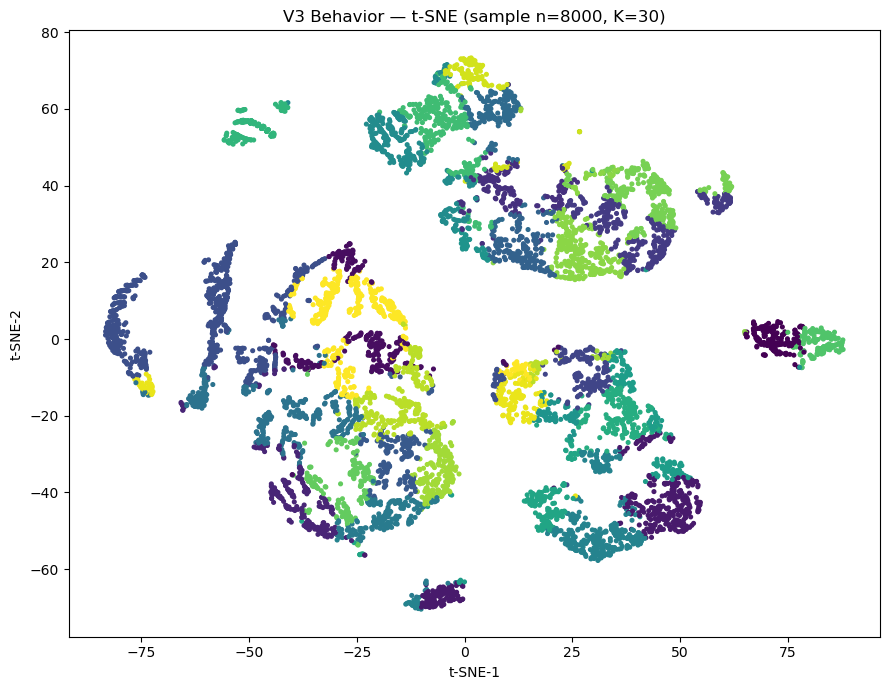

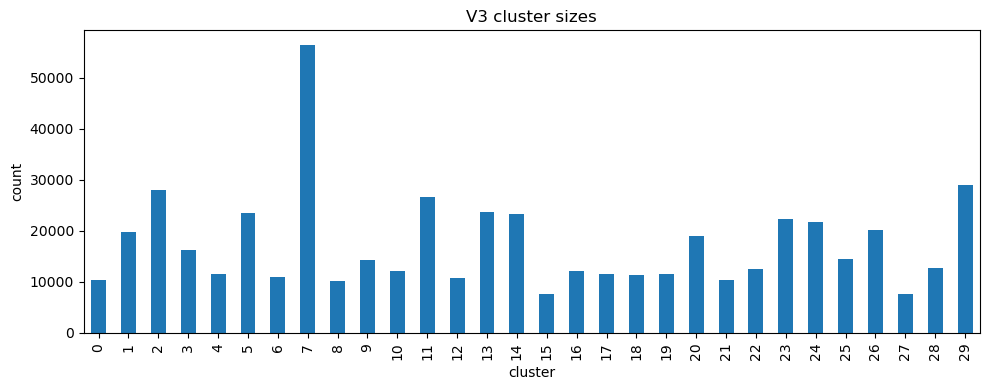

Top-10 cluster sizes:
 7     56461
29    28960
2     28072
11    26673
13    23769
5     23458
14    23253
23    22257
24    21785
26    20187
Name: count, dtype: int64
[V3] silhouette(cosine,n=10000)=0.3886 | DB=1.221 (↓) | CH=130037.8 (↑)


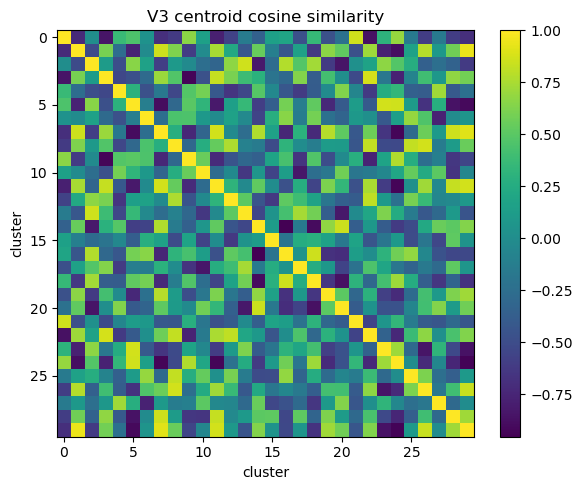

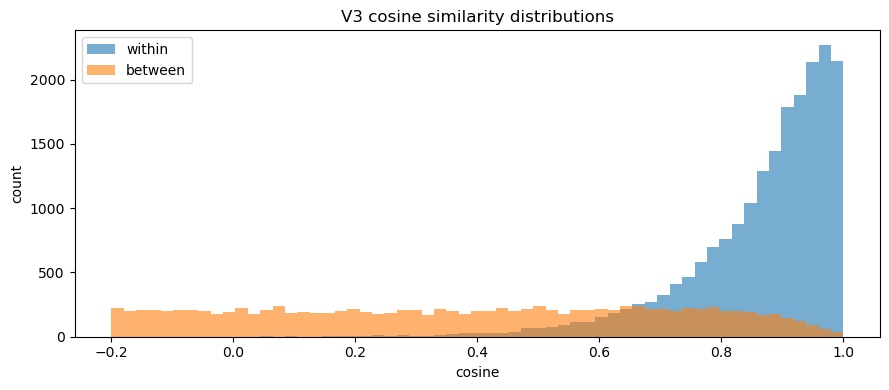

[V3] mean cos — within:0.866 | between:0.000 | centroid-between:-0.012


In [25]:
# —— V3 行为视角：聚类 + 可视化 + 评估（仅用 ./data/v3_behavior_vectors.csv）——
import pandas as pd, numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

# 1) 读取向量并（稳妥起见）再 L2 归一一次
v3 = pd.read_csv("./data/v3_behavior_vectors.csv")
ids = v3["Id"].to_numpy(np.int64)
X = v3.drop(columns=["Id"]).to_numpy(np.float32)
X /= (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
n, d = X.shape
print("V3 loaded:", X.shape)

# 2) 聚类（MiniBatchKMeans；K 用简易启发式，可按需调）
K = int(max(6, min(30, round(np.sqrt(max(2000, n)/250)))))  # 约 8~30
kmeans = MiniBatchKMeans(n_clusters=K, random_state=42, batch_size=10000, n_init=10)
labels = kmeans.fit_predict(X)
pd.DataFrame({"Id": ids, "label": labels}).to_csv("./data/v3_clusters.csv", index=False)
print(f"saved clusters -> ./data/v3_clusters.csv | K={K}")

# 3) 可视化：t-SNE 抽样散点 + 簇规模柱状图（如绘图环境异常将跳过）
try:
    import matplotlib.pyplot as plt

    rng = np.random.default_rng(42)
    plot_size = min(8000, n)
    idx = rng.choice(n, size=plot_size, replace=False)

    Z50 = TruncatedSVD(n_components=min(50, d), random_state=42).fit_transform(X[idx])
    Z50 /= (np.linalg.norm(Z50, axis=1, keepdims=True) + 1e-12)
    perp = int(max(5, min(50, (plot_size - 1)//3, max(5, plot_size//40))))
    Y = TSNE(n_components=2, perplexity=perp, learning_rate=200, init="pca", random_state=42)\
        .fit_transform(Z50.astype(np.float32))

    plt.figure(figsize=(9,7))
    plt.scatter(Y[:,0], Y[:,1], s=7, c=labels[idx])
    plt.title(f"V3 Behavior — t-SNE (sample n={plot_size}, K={K})")
    plt.xlabel("t-SNE-1"); plt.ylabel("t-SNE-2")
    plt.tight_layout(); plt.show()

    sizes = pd.Series(labels).value_counts().sort_index()
    plt.figure(figsize=(10,4))
    sizes.plot(kind="bar")
    plt.title("V3 cluster sizes"); plt.xlabel("cluster"); plt.ylabel("count")
    plt.tight_layout(); plt.show()

    print("Top-10 cluster sizes:\n", sizes.sort_values(ascending=False).head(10))
except Exception as e:
    print("Plotting skipped due to error:", repr(e))

# 4) 评估：轮廓系数（cosine, 抽样）、DB、CH；质心余弦热图；组内/组间相似度分布
try:
    import matplotlib.pyplot as plt
    from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

    FEAT, LAB = X, labels
    m = int(min(10000, FEAT.shape[0]))
    idx_eval = np.random.default_rng(42).choice(FEAT.shape[0], size=m, replace=False)
    sil = silhouette_score(FEAT[idx_eval], LAB[idx_eval], metric="cosine")
    db  = davies_bouldin_score(FEAT, LAB)
    ch  = calinski_harabasz_score(FEAT, LAB)
    print(f"[V3] silhouette(cosine,n={m})={sil:.4f} | DB={db:.3f} (↓) | CH={ch:.1f} (↑)")

    uniq = np.unique(LAB); K = len(uniq)
    cent = []
    for k in uniq:
        mk = (LAB==k)
        c = FEAT[mk].mean(axis=0); c /= (np.linalg.norm(c)+1e-12)
        cent.append(c)
    Cmat = np.vstack(cent) @ np.vstack(cent).T
    plt.figure(figsize=(6,5))
    plt.imshow(Cmat, aspect="auto"); plt.colorbar(); plt.title("V3 centroid cosine similarity")
    plt.xlabel("cluster"); plt.ylabel("cluster"); plt.tight_layout(); plt.show()

    rng = np.random.default_rng(1)
    bins = np.linspace(-0.2, 1.0, 60)

    s_in = []
    for k in uniq:
        idxk = np.where(LAB==k)[0]
        if idxk.size < 2: continue
        s = min(20000//len(uniq), idxk.size)
        a = rng.choice(idxk, size=s, replace=True)
        b = rng.choice(idxk, size=s, replace=True)
        s_in.append(np.sum(FEAT[a]*FEAT[b], axis=1))
    s_in = np.concatenate(s_in) if len(s_in) else np.array([])

    s = 20000
    a = rng.choice(FEAT.shape[0], size=s, replace=True)
    b = rng.choice(FEAT.shape[0], size=s, replace=True)
    mask = LAB[a] != LAB[b]
    s_out = np.sum(FEAT[a[mask]]*FEAT[b[mask]], axis=1)

    plt.figure(figsize=(9,4))
    plt.hist(s_in, bins=bins, alpha=0.6, label="within")
    plt.hist(s_out, bins=bins, alpha=0.6, label="between")
    plt.legend(); plt.title("V3 cosine similarity distributions"); plt.xlabel("cosine"); plt.ylabel("count")
    plt.tight_layout(); plt.show()

    off = Cmat[~np.eye(K, dtype=bool)]
    print(f"[V3] mean cos — within:{np.nanmean(s_in):.3f} | between:{np.nanmean(s_out):.3f} | centroid-between:{off.mean():.3f}")
except Exception as e:
    print("Evaluation/plotting skipped due to error:", repr(e))


In [27]:
# —— V1+V2+V3 · 第1步：向量早期融合（加权拼接→L2归一）并保存 ——
import pandas as pd, numpy as np

# 1) 读取三视角向量，并按 Id 取交集对齐（仅保留三者都存在的样本）
v1 = pd.read_csv("./data/v1_taggraph_vectors.csv").set_index("Id")
v2 = pd.read_csv("./data/v2_textgraph_vectors.csv").set_index("Id")
v3 = pd.read_csv("./data/v3_behavior_vectors.csv").set_index("Id")
ids = v1.index.intersection(v2.index).intersection(v3.index)

# 2) 取出数值矩阵并各自做行向量 L2 归一化（便于后续用余弦度量）
X1 = v1.loc[ids].to_numpy(np.float32)
X2 = v2.loc[ids].to_numpy(np.float32)
X3 = v3.loc[ids].to_numpy(np.float32)
X1 /= (np.linalg.norm(X1, axis=1, keepdims=True) + 1e-12)
X2 /= (np.linalg.norm(X2, axis=1, keepdims=True) + 1e-12)
X3 /= (np.linalg.norm(X3, axis=1, keepdims=True) + 1e-12)

# 3) 加权拼接（早期融合），再对拼接后的向量整体 L2 归一化
lam1, lam2, lam3 = 1.0, 0.8, 0.5
Z = np.concatenate([lam1*X1, lam2*X2, lam3*X3], axis=1).astype(np.float32)
Z /= (np.linalg.norm(Z, axis=1, keepdims=True) + 1e-12)

# 4) 保存到 ./data/v123_fused_vectors.csv（列：Id,f0..fM）
cols = ["Id"] + [f"f{i}" for i in range(Z.shape[1])]
out = pd.DataFrame(np.column_stack([ids.to_numpy(np.int64), Z]), columns=cols)
out.to_csv("./data/v123_fused_vectors.csv", index=False)

print("aligned ids:", len(ids),
      "| dims:", (X1.shape[1], X2.shape[1], X3.shape[1]),
      "-> fused:", Z.shape,
      "| saved -> ./data/v123_fused_vectors.csv")


aligned ids: 132485 | dims: (128, 128, 8) -> fused: (132485, 264) | saved -> ./data/v123_fused_vectors.csv


In [28]:
# —— V1+V2+V3 · 第2步：仅基于融合向量进行聚类（MiniBatchKMeans），并保存标签 ——
import pandas as pd, numpy as np
from sklearn.cluster import MiniBatchKMeans

# 1) 读取上一步保存的融合向量，并（稳妥）做一次行向量 L2 归一化
fused = pd.read_csv("./data/v123_fused_vectors.csv")
ids = fused["Id"].to_numpy(np.int64)
X = fused.drop(columns=["Id"]).to_numpy(np.float32)
X /= (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)   # 便于余弦度量/稳定聚类

# 2) 设定簇数 K（启发式：随样本量增长缓慢；后续可调参/换无参密度法）
n = X.shape[0]
K = int(max(10, min(40, round(np.sqrt(max(3000, n)/250)))))  # 约 10–40 之间
print(f"fused samples: {n}, using K={K}")

# 3) MiniBatchKMeans 聚类（适合大数据；batch_size 可按机器内存调大/调小）
kmeans = MiniBatchKMeans(n_clusters=K, random_state=42, batch_size=20000, n_init=10)
labels = kmeans.fit_predict(X)

# 4) 保存聚类结果到 ./data/v123_clusters.csv（仅包含 Id 与 label）
out = pd.DataFrame({"Id": ids, "label": labels})
out.to_csv("./data/v123_clusters.csv", index=False)

# 5) 输出簇规模概览，便于快速检查是否退化（例如单一巨簇或大量小簇）
sizes = out["label"].value_counts().sort_index()
print("clusters saved -> ./data/v123_clusters.csv")
print("cluster sizes (head):")
print(sizes.head(10))


fused samples: 132485, using K=23
clusters saved -> ./data/v123_clusters.csv
cluster sizes (head):
label
0    19241
1     9532
2     1929
3     3685
4     6836
5     3282
6     8819
7     4688
8     9147
9     5674
Name: count, dtype: int64


fused loaded: (132485, 264)
[V123] silhouette(cosine,n=10000)=0.1938 | DB=2.785 (↓) | CH=2882.8 (↑)
[V123] centroid mean cosine (off-diagonal): 0.246
[V123] mean cos — within:0.479 | between:0.118


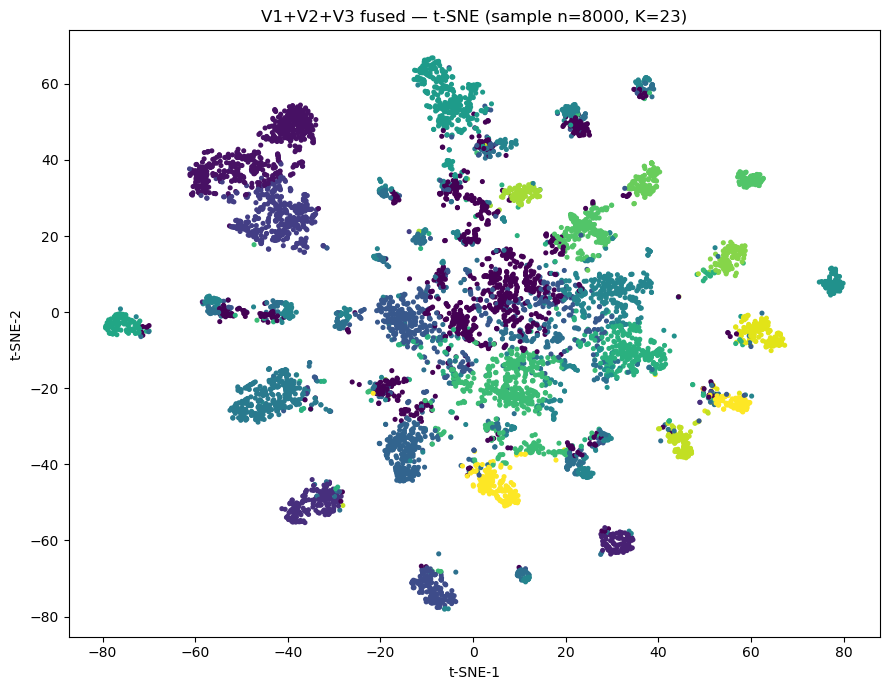

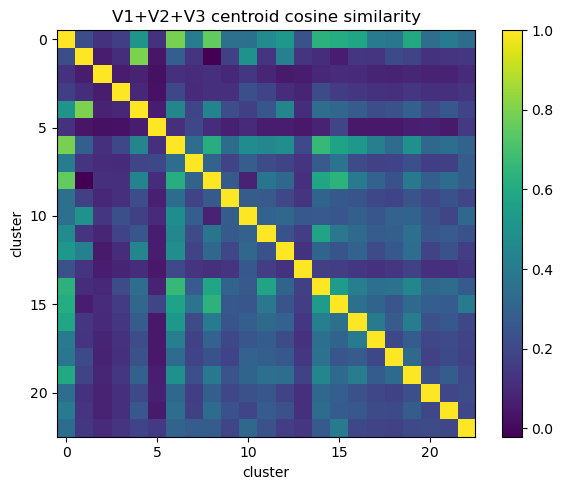

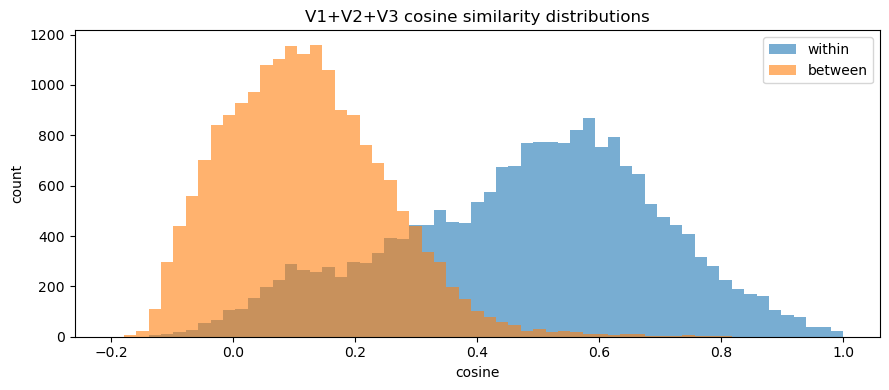

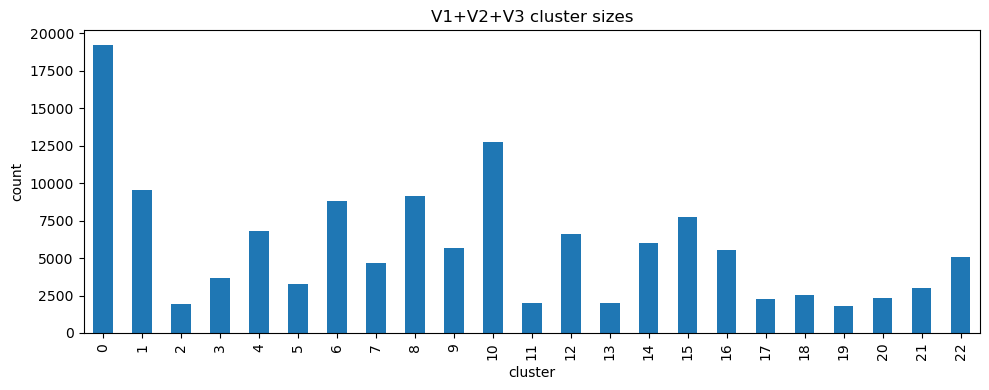

Top-10 cluster sizes:
 0     19241
10    12766
1      9532
8      9147
6      8819
15     7737
4      6836
12     6638
14     6015
9      5674
Name: count, dtype: int64


In [29]:
# —— V1+V2+V3 · 第3步：融合向量的聚类评估 + 可视化 —— 
import pandas as pd, numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

# 1) 读取融合向量与聚类标签（来自上两步的输出）
fv = pd.read_csv("./data/v123_fused_vectors.csv")
cl = pd.read_csv("./data/v123_clusters.csv")
df = fv.merge(cl, on="Id", how="inner")
X = df.drop(columns=["Id","label"]).to_numpy(np.float32)
X /= (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)   # 行向量 L2 归一
labels = df["label"].to_numpy(np.int32)
n = X.shape[0]; print("fused loaded:", X.shape)

# 2) 评估指标：silhouette(cosine，抽样)、Davies–Bouldin、Calinski–Harabasz
m = int(min(10000, n))
idx_eval = np.random.default_rng(42).choice(n, size=m, replace=False)
sil = silhouette_score(X[idx_eval], labels[idx_eval], metric="cosine")
db  = davies_bouldin_score(X, labels)
ch  = calinski_harabasz_score(X, labels)
print(f"[V123] silhouette(cosine,n={m})={sil:.4f} | DB={db:.3f} (↓) | CH={ch:.1f} (↑)")

# 3) 质心余弦相似度热图数据：先求各簇质心并 L2 归一，再做矩阵乘法
uniq = np.unique(labels); K = len(uniq)
cent = []
for k in uniq:
    mk = (labels == k)
    c = X[mk].mean(axis=0); c /= (np.linalg.norm(c) + 1e-12)
    cent.append(c)
Cmat = np.vstack(cent) @ np.vstack(cent).T   # (K,K) 质心余弦
off = Cmat[~np.eye(K, dtype=bool)]
print(f"[V123] centroid mean cosine (off-diagonal): {off.mean():.3f}")

# 4) 组内/组间相似度分布（抽样对）
rng = np.random.default_rng(1)
bins = np.linspace(-0.2, 1.0, 60)

# 组内：各簇均匀抽样若干对
s_in = []
for k in uniq:
    idxk = np.where(labels == k)[0]
    if idxk.size < 2: 
        continue
    s = min(20000 // max(1, K), idxk.size)
    a = rng.choice(idxk, size=s, replace=True)
    b = rng.choice(idxk, size=s, replace=True)
    s_in.append(np.sum(X[a] * X[b], axis=1))
s_in = np.concatenate(s_in) if len(s_in) else np.array([])

# 组间：全局随机对后筛不同簇
s = 20000
a = rng.choice(n, size=s, replace=True)
b = rng.choice(n, size=s, replace=True)
mask = labels[a] != labels[b]
s_out = np.sum(X[a[mask]] * X[b[mask]], axis=1)

print(f"[V123] mean cos — within:{np.nanmean(s_in):.3f} | between:{np.nanmean(s_out):.3f}")

# 5) 可视化：t-SNE 抽样散点 + 质心热图 + 相似度直方图 + 簇规模柱状图（绘图异常则跳过）
try:
    import matplotlib.pyplot as plt

    # 5.1 t-SNE（先 SVD→50D，加速）
    plot_size = min(8000, n)
    idx = rng.choice(n, size=plot_size, replace=False)
    Z50 = TruncatedSVD(n_components=min(50, X.shape[1]), random_state=42).fit_transform(X[idx])
    Z50 /= (np.linalg.norm(Z50, axis=1, keepdims=True) + 1e-12)
    perp = int(max(5, min(50, (plot_size - 1)//3, max(5, plot_size//40))))
    Y = TSNE(n_components=2, perplexity=perp, learning_rate=200, init="pca", random_state=42)\
        .fit_transform(Z50.astype(np.float32))

    plt.figure(figsize=(9,7))
    plt.scatter(Y[:,0], Y[:,1], s=7, c=labels[idx])
    plt.title(f"V1+V2+V3 fused — t-SNE (sample n={plot_size}, K={K})")
    plt.xlabel("t-SNE-1"); plt.ylabel("t-SNE-2")
    plt.tight_layout(); plt.show()

    # 5.2 质心余弦相似度热图
    plt.figure(figsize=(6,5))
    plt.imshow(Cmat, aspect="auto")
    plt.colorbar(); plt.title("V1+V2+V3 centroid cosine similarity")
    plt.xlabel("cluster"); plt.ylabel("cluster")
    plt.tight_layout(); plt.show()

    # 5.3 组内/组间相似度直方图
    plt.figure(figsize=(9,4))
    plt.hist(s_in, bins=bins, alpha=0.6, label="within")
    plt.hist(s_out, bins=bins, alpha=0.6, label="between")
    plt.legend(); plt.title("V1+V2+V3 cosine similarity distributions")
    plt.xlabel("cosine"); plt.ylabel("count")
    plt.tight_layout(); plt.show()

    # 5.4 簇规模柱状图
    sizes = pd.Series(labels).value_counts().sort_index()
    plt.figure(figsize=(10,4))
    sizes.plot(kind="bar")
    plt.title("V1+V2+V3 cluster sizes"); plt.xlabel("cluster"); plt.ylabel("count")
    plt.tight_layout(); plt.show()

    print("Top-10 cluster sizes:\n", sizes.sort_values(ascending=False).head(10))
except Exception as e:
    print("Plotting skipped due to error:", repr(e))


In [35]:
# —— 簇解释 · 第1步：统计每个簇的 Top Tags，并保存 —— 
import pandas as pd

# 1) 读融合聚类标签与元数据中的 Tags 列
cl = pd.read_csv("./data/v123_clusters.csv")                     # 列：Id,label
md = pd.read_csv("./data/metadata_merged.csv", usecols=["Id","Tags"])

# 2) 解析标签：按逗号切分，去空白、转小写、去空
md["Tags"] = md["Tags"].fillna("").astype(str)
tags = md["Tags"].str.split(",")
df = pd.DataFrame({"Id": md["Id"].repeat(tags.str.len()).to_numpy(),
                   "tag": [t.strip().lower() for sub in tags for t in sub]})
df = df[df["tag"]!=""]

# 3) 合并聚类标签，统计每个簇内各 tag 的出现次数并取 Top-10
df = df.merge(cl, on="Id", how="inner")
topk = (df.groupby(["label","tag"]).size().reset_index(name="cnt")
          .sort_values(["label","cnt"], ascending=[True,False])
          .groupby("label").head(10))

# 4) 汇总成每簇一行：簇大小 + Top10 标签（带计数），保存
sizes = cl["label"].value_counts().rename_axis("label").reset_index(name="size")
topk["tag_cnt"] = topk["tag"] + ":" + topk["cnt"].astype(str)
summary = topk.groupby("label")["tag_cnt"].apply(lambda s: ", ".join(s)).reset_index()
summary = sizes.merge(summary, on="label", how="left").rename(columns={"tag_cnt":"top10_tags"})
summary.to_csv("./data/v123_cluster_summary_tags.csv", index=False)
print("saved -> ./data/v123_cluster_summary_tags.csv", "| rows:", len(summary))


saved -> ./data/v123_cluster_summary_tags.csv | rows: 23


In [36]:
# —— 簇解释 · 第2步：统计每簇 Top Tokens（覆盖度优先，其次总权重），合并到摘要 ——
import pandas as pd
import numpy as np

# 1) 读取聚类标签与 Text-Graph 边（每条边：文档Id-关键词token-权重）
cl = pd.read_csv("./data/v123_clusters.csv")            # Id, label
edges = pd.read_csv("./data/textgraph_edges.csv")       # Id, token, weight

# 2) 关联簇标签；同一文档-词在前面已去重，这里再稳妥去重一次
e = edges.merge(cl, on="Id", how="inner").drop_duplicates(subset=["Id","token","label"])

# 3) 统计每簇内每个 token 的覆盖度（出现该词的文档数）与总权重
g = e.groupby(["label","token"]).agg(
        cover=("Id", "nunique"),
        wsum = ("weight", "sum")
    ).reset_index()

# 4) 对每个簇按覆盖度降序、若覆盖相同按总权重降序取 Top-10
g = g.sort_values(["label","cover","wsum"], ascending=[True, False, False])
top_tok = g.groupby("label").head(10).copy()
top_tok["token_stat"] = top_tok["token"] + ":" + top_tok["cover"].astype(str) + f" (w={np.round(top_tok['wsum'],2)})"

# 5) 把 Top-10 tokens 汇总成每簇一行，并与上一步的标签摘要合并
tok_sum = top_tok.groupby("label")["token_stat"].apply(lambda s: ", ".join(s)).reset_index()
tags_sum = pd.read_csv("./data/v123_cluster_summary_tags.csv")   # 上一步保存的摘要：label, size, top10_tags
summary = tags_sum.merge(tok_sum, on="label", how="left").rename(columns={"token_stat":"top10_tokens"})

# 6) 保存新的摘要文件
summary.to_csv("./data/v123_cluster_summary_tags_tokens.csv", index=False)
print("saved -> ./data/v123_cluster_summary_tags_tokens.csv", "| rows:", len(summary))


saved -> ./data/v123_cluster_summary_tags_tokens.csv | rows: 23


In [37]:
# —— 簇解释 · 第3步：为每个簇补充“行为画像”，并合并到最终摘要 ——
import pandas as pd
import numpy as np

# 1) 读取融合聚类标签与元数据（只取行为相关列）
cl = pd.read_csv("./data/v123_clusters.csv")  # Id, label
md = pd.read_csv("./data/metadata_merged.csv",
                 usecols=["Id",
                          "TotalViews","TotalDownloads","TotalVotes","TotalKernels",
                          "TotalViews_log1p","TotalDownloads_log1p","TotalVotes_log1p","TotalKernels_log1p",
                          "Medal","age_days","days_since_last_activity","active_30d"])

# 2) 预处理：缺失与类型（active_30d 转为 0/1；Medal 缺失视为 0）
md["Medal"] = pd.to_numeric(md["Medal"], errors="coerce").fillna(0).astype(np.float32)
md["active_30d"] = (md["active_30d"].astype(str).str.lower()
                    .map({"true":1,"false":0,"1":1,"0":0})).fillna(0).astype(np.int8)

num_cols = ["TotalViews","TotalDownloads","TotalVotes","TotalKernels",
            "TotalViews_log1p","TotalDownloads_log1p","TotalVotes_log1p","TotalKernels_log1p",
            "Medal","age_days","days_since_last_activity","active_30d"]
for c in num_cols:
    md[c] = pd.to_numeric(md[c], errors="coerce").fillna(0)

# 3) 合并聚类标签并聚合：均值/中位数（活跃率=active_30d 的均值）
df = md.merge(cl, on="Id", how="inner")
agg = df.groupby("label").agg(
    size=("Id","size"),
    views_mean=("TotalViews","mean"),        views_med=("TotalViews","median"),
    dls_mean=("TotalDownloads","mean"),      dls_med=("TotalDownloads","median"),
    votes_mean=("TotalVotes","mean"),        votes_med=("TotalVotes","median"),
    kernels_mean=("TotalKernels","mean"),    kernels_med=("TotalKernels","median"),
    v_log_mean=("TotalViews_log1p","mean"),  d_log_mean=("TotalDownloads_log1p","mean"),
    vt_log_mean=("TotalVotes_log1p","mean"), k_log_mean=("TotalKernels_log1p","mean"),
    medal_mean=("Medal","mean"),
    age_mean=("age_days","mean"),            age_med=("age_days","median"),
    idle_mean=("days_since_last_activity","mean"), idle_med=("days_since_last_activity","median"),
    active_rate=("active_30d","mean")
).reset_index()

# 4) 与前一步的 “Top Tags + Top Tokens” 合并，保存最终摘要
prev = pd.read_csv("./data/v123_cluster_summary_tags_tokens.csv")  # label, size, top10_tags, top10_tokens
summary = prev.drop(columns=["size"], errors="ignore").merge(agg, on="label", how="right")

summary.to_csv("./data/v123_cluster_summary.csv", index=False)
print("saved -> ./data/v123_cluster_summary.csv", "| rows:", len(summary))


saved -> ./data/v123_cluster_summary.csv | rows: 23


In [38]:
# —— 簇解释 · 第4步：为每个簇选 Top-10 代表数据集（离质心最近），并落盘 ——
import pandas as pd, numpy as np

# 1) 读融合向量与聚类标签，确保向量已 L2 归一
fv = pd.read_csv("./data/v123_fused_vectors.csv")   # Id,f0..fM
cl = pd.read_csv("./data/v123_clusters.csv")        # Id,label
dfv = fv.merge(cl, on="Id", how="inner")

ids = dfv["Id"].to_numpy(np.int64)
labels = dfv["label"].to_numpy(np.int32)
X = dfv.drop(columns=["Id","label"]).to_numpy(np.float32)
X /= (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)

# 2) 计算每个簇的 L2 归一化质心
uniq = np.unique(labels)
cent = {}
for k in uniq:
    idxk = np.where(labels==k)[0]
    c = X[idxk].mean(axis=0)
    c /= (np.linalg.norm(c) + 1e-12)
    cent[k] = c

# 3) 对每个簇，按与质心的余弦相似度排序，取 Top-10
rows = []
for k in uniq:
    idxk = np.where(labels==k)[0]
    sims = X[idxk] @ cent[k]             # 余弦 = 内积（向量已归一）
    order = np.argsort(-sims)[:10]       # 相似度从高到低取前10
    for rank, j in enumerate(order, 1):
        rows.append((int(k), int(ids[idxk[j]]), float(sims[j]), rank))

rep = pd.DataFrame(rows, columns=["label","Id","cos_to_centroid","rank"])

# 4) 合并元数据方便阅读（Title/Slug/Tags），并保存
md = pd.read_csv("./data/metadata_merged.csv", usecols=["Id","Title","Slug","Tags"])
rep = rep.merge(md, on="Id", how="left")
rep = rep.sort_values(["label","rank"])
rep.to_csv("./data/v123_cluster_representatives.csv", index=False)

print("saved -> ./data/v123_cluster_representatives.csv", "| rows:", len(rep))
print(rep.head(12))


saved -> ./data/v123_cluster_representatives.csv | rows: 230
    label       Id  cos_to_centroid  rank  \
0       0    70594         0.730611     1   
1       0  1229045         0.722130     2   
2       0  2042069         0.721811     3   
3       0  1566039         0.718336     4   
4       0  1631814         0.713876     5   
5       0  1278612         0.712005     6   
6       0  2041575         0.711944     7   
7       0  1802574         0.711690     8   
8       0  1323529         0.711660     9   
9       0  1344270         0.711479    10   
10      1  5255928         0.952728     1   
11      1  5252427         0.952196     2   

                                                Title  \
0                       Visitors to Taiwan By Purpose   
1                         Cities and Towns of Germany   
2                          Australia Immigration data   
3                         Regional Macroeconomic data   
4            Pin codes in India with location mapping   
5          

In [39]:
# —— 簇解释 · 第5步：基于 Top-Tags/Top-Tokens 自动命名每个簇，并“直接展示” —— 
import re, pandas as pd, numpy as np

# 1) 读取上一阶段的摘要与代表样本（用于备选示例标题）
sumy = pd.read_csv("./data/v123_cluster_summary.csv")                  # 含：label,size,top10_tags,top10_tokens,行为画像…
reps = pd.read_csv("./data/v123_cluster_representatives.csv")          # 含：label,Id,cos_to_centroid,rank,Title,Slug,Tags

# 2) 解析工具：将 "tag:cnt, ..." / "token:cover (w=…)" 解析成可排序列表
def parse_tag_list(s):
    out = []
    if not isinstance(s, str) or not s.strip(): 
        return out
    for it in s.split(","):
        it = it.strip()
        if not it: 
            continue
        if ":" in it:
            k,v = it.split(":",1)
            try:
                out.append((k.strip(), int(re.sub(r"[^\d]", "", v)) ))
            except:
                out.append((k.strip(), 0))
        else:
            out.append((it, 0))
    return out

def parse_tok_list(s):
    out = []
    if not isinstance(s, str) or not s.strip(): 
        return out
    for it in s.split(","):
        it = it.strip()
        if not it: 
            continue
        # 形如 "time series:123 (w=45.6)"
        m = re.match(r"^(.*?):\s*([0-9]+)", it)
        if m:
            tok = m.group(1).strip()
            cov = int(m.group(2))
            out.append((tok, cov))
        else:
            out.append((it, 0))
    return out

# 3) 小工具：格式化名称（Title Case，但保留大写缩写）
def neat(s):
    s = s.strip()
    # 对由字母/数字与连字符、下划线、空格组成的词做首字母大写；全大写/含数字的词保持
    words = re.split(r"\s+|[_/]", s)
    nw = []
    for w in words:
        if not w: 
            continue
        if w.isupper() or re.search(r"\d", w):
            nw.append(w)
        else:
            nw.append(w[0].upper()+w[1:] if len(w)>1 else w.upper())
    return " ".join(nw)

# 4) 生成簇名：规则 = 主标签 + 次标签/强 token +（可选）风格词
rows = []
for _, r in sumy.iterrows():
    k = int(r["label"])
    tags = parse_tag_list(r.get("top10_tags", ""))
    toks = parse_tok_list(r.get("top10_tokens", ""))
    size = int(r.get("size", 0)) if "size" in r else None

    # 4.1 选主/次标签
    tags_sorted = sorted(tags, key=lambda x: x[1], reverse=True)
    primary = neat(tags_sorted[0][0]) if tags_sorted else f"Cluster {k}"
    secondary = ""
    if len(tags_sorted) > 1 and (tags_sorted[1][1] >= 0.4*tags_sorted[0][1]):
        secondary = neat(tags_sorted[1][0])

    # 4.2 选两个高覆盖 token（与标签去重/去包含）
    tag_set = {t[0].lower() for t in tags_sorted[:3]}
    toks_sorted = [t for t in sorted(toks, key=lambda x: x[1], reverse=True)
                   if all(tt not in t[0].lower() for tt in tag_set)]
    spec = ", ".join(neat(t[0]) for t in toks_sorted[:2])

    # 4.3 兜底：若 tokens 很少，尝试用代表样本的 Title 关键短语（前2个）
    if not spec:
        rep_titles = reps.loc[(reps["label"]==k)&(reps["rank"]<=3), "Title"].fillna("").astype(str).tolist()
        phrases = []
        for t in rep_titles:
            # 取长度 2–3 的高频词片段
            toks_ = [w for w in re.findall(r"[A-Za-z][A-Za-z0-9\-+_]{2,}", t) if w.lower() not in tag_set]
            phrases.extend(toks_[:3])
        if phrases:
            spec = ", ".join(neat(p) for p in phrases[:2])

    # 4.4 组合命名：Primary[/Secondary] — Spec
    if secondary and spec:
        name = f"{primary} / {secondary} — {spec}"
    elif secondary:
        name = f"{primary} / {secondary}"
    elif spec:
        name = f"{primary} — {spec}"
    else:
        name = primary

    rows.append({"label": k, "cluster_name": name, "size": size})

names = pd.DataFrame(rows).sort_values(["label"]).reset_index(drop=True)

# 5) 合并回摘要并保存；同时“直接展示”前若干行
final = sumy.merge(names[["label","cluster_name"]], on="label", how="left")
final.to_csv("./data/v123_cluster_summary_named.csv", index=False)

print("saved -> ./data/v123_cluster_summary_named.csv | rows:", len(final))
print("\n== 示例（前15个簇）==")
print(final[["label","cluster_name","size"]].sort_values("label").head(15).to_string(index=False))


saved -> ./data/v123_cluster_summary_named.csv | rows: 23

== 示例（前15个簇）==
 label                            cluster_name  size
     0          Business / Tabular — Api, Open 19241
     1                Business — Stock, Market  9532
     2              Exercise — Weights, Fitbit  1929
     3                          Music — Yt, Bn  3685
     4              Business — Sales, Customer  6836
     5                  Cancer — Breast, Tumor  3282
     6    Tabular / Beginner — Price, Customer  8819
     7                Health — Medical, Images  4688
     8        Food / Tabular — Train, Diabetes  9147
     9           Education — Learning, Student  5674
    10 Transportation / Travel — Images, Train 12766
    11                Literature — Books, Book  1970
    12     Investing / Finance — Stock, Market  6638
    13           Law — Checkpoint, Checkpoints  1996
    14        Text / Nlp — Language, Sentiment  6015


In [40]:
# —— V1+V2+V3 · 第6步：用融合向量建立全局 kNN（余弦相似度）并落盘 ——
import pandas as pd, numpy as np
from sklearn.neighbors import NearestNeighbors

# 1) 读取融合向量（已归一），以及可读元数据
fv = pd.read_csv("./data/v123_fused_vectors.csv")   # 列：Id,f0..fM
md = pd.read_csv("./data/metadata_merged.csv", usecols=["Id","Title","Slug","Tags"])

# （可选）子集试跑：把 N_LIMIT 设为整数可先在子集上验证速度/内存
N_LIMIT = None   # 例如 50000；None 表示全量
if N_LIMIT is not None:
    fv = fv.sample(n=min(N_LIMIT, len(fv)), random_state=42).reset_index(drop=True)

ids = fv["Id"].to_numpy(np.int64)
X = fv.drop(columns=["Id"]).to_numpy(np.float32)
X /= (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)   # 再保险一次 L2 归一

# 2) 拟合 kNN（cosine 距离；brute 全量精确检索）
K = 50 + 1   # +1 是为了包含自身，稍后会去掉自己
knn = NearestNeighbors(n_neighbors=K, metric="cosine", algorithm="brute")
knn.fit(X)
dist, idx = knn.kneighbors(X, n_neighbors=K, return_distance=True)  # dist ∈ [0,2] for cosine? 这里是 1-cos

# 3) 去掉“自身”为第一个邻居；转为相似度（cos = 1 - dist）
dist = dist[:, 1:]
idx  = idx[:, 1:]
sims = 1.0 - dist

# 4) 组装为长表并合并可读信息；保存
rows = []
for i in range(idx.shape[0]):
    qid = ids[i]
    nbr_ids = ids[idx[i]]
    nbr_sims = sims[i]
    for r, (nid, sc) in enumerate(zip(nbr_ids, nbr_sims), start=1):
        rows.append((qid, int(nid), float(sc), r))

res = pd.DataFrame(rows, columns=["QueryId","NeighborId","CosineSim","Rank"])
res = (res.merge(md.rename(columns={"Id":"QueryId","Title":"QueryTitle","Slug":"QuerySlug","Tags":"QueryTags"}), on="QueryId", how="left")
          .merge(md.rename(columns={"Id":"NeighborId","Title":"NeighborTitle","Slug":"NeighborSlug","Tags":"NeighborTags"}), on="NeighborId", how="left"))

out_path = "./data/v123_knn_top50.csv"
res.to_csv(out_path, index=False)
print("kNN saved ->", out_path, "| rows:", len(res), "| queries:", len(ids), "| topK:", K-1)
print(res.head(12))


kNN saved -> ./data/v123_knn_top50.csv | rows: 6624250 | queries: 132485 | topK: 50
    QueryId  NeighborId  CosineSim  Rank                      QueryTitle  \
0         6       22409   0.879766     1  2013 American Community Survey   
1         6        1352   0.865527     2  2013 American Community Survey   
2         6      889104   0.855208     3  2013 American Community Survey   
3         6      604963   0.842730     4  2013 American Community Survey   
4         6     2446556   0.820656     5  2013 American Community Survey   
5         6         594   0.810495     6  2013 American Community Survey   
6         6     3742348   0.808118     7  2013 American Community Survey   
7         6       64789   0.805976     8  2013 American Community Survey   
8         6     1212860   0.798796     9  2013 American Community Survey   
9         6        1682   0.791103    10  2013 American Community Survey   
10        6        1486   0.790793    11  2013 American Community Survey   
11  